In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [5]:
import os

print(os.listdir("../data/processed"))

['aum_by_fund_house.csv', 'Axis_Bluechip.csv', 'fund_master.csv', 'hdfc_top100_live_nav.csv', 'ICICI_Bluechip.csv', 'investor_transactions.csv', 'Kotak_Bluechip.csv', 'nav_history.csv', 'Nippon_LargeCap.csv', 'portfolio_holdings.csv', 'SBI_Bluechip.csv', 'scheme_performance.csv']


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [7]:
nav_history = pd.read_csv("../data/raw/nav_history.csv")
fund_master = pd.read_csv("../data/raw/fund_master.csv")
scheme_performance = pd.read_csv("../data/raw/scheme_performance.csv")

In [8]:
nav_history["date"] = pd.to_datetime(
    nav_history["date"],
    format="%d-%m-%Y"
)

In [9]:
nav_history = nav_history.sort_values(["amfi_code", "date"])

nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"].pct_change()
)

In [10]:
nav_history[["amfi_code", "date", "nav", "daily_return"]].head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [11]:
nav_history.dtypes

amfi_code                int64
date            datetime64[us]
nav                    float64
daily_return           float64
dtype: object

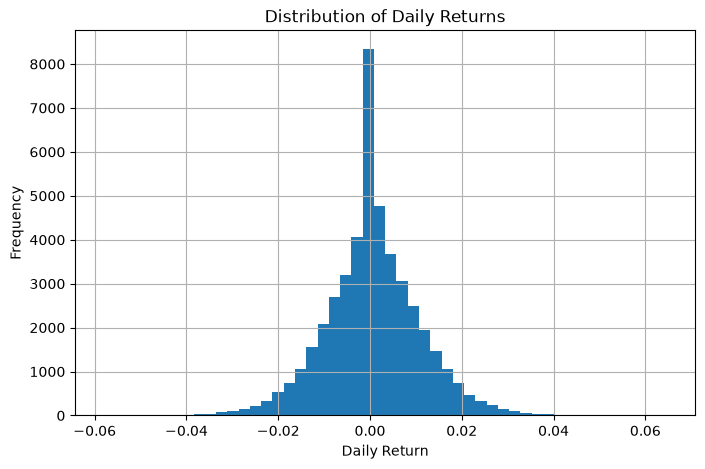

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

nav_history["daily_return"].hist(bins=50)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.grid(True)
plt.show()

In [13]:
nav_history["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [14]:
# CAGR Calculation

In [15]:
from datetime import timedelta

# Ensure data is sorted
nav_history = nav_history.sort_values(["amfi_code", "date"])

latest_date = nav_history["date"].max()

years = [1, 3, 5]

cagr_results = []

for scheme in nav_history["amfi_code"].unique():

    fund = nav_history[nav_history["amfi_code"] == scheme]

    latest_nav = fund.iloc[-1]["nav"]

    row = {"amfi_code": scheme}

    for y in years:

        start_date = latest_date - pd.DateOffset(years=y)

        temp = fund[fund["date"] >= start_date]

        if len(temp) > 0:

            start_nav = temp.iloc[0]["nav"]

            cagr = (latest_nav / start_nav) ** (1 / y) - 1

            row[f"CAGR_{y}Y"] = cagr

        else:

            row[f"CAGR_{y}Y"] = np.nan

    cagr_results.append(row)

cagr_df = pd.DataFrame(cagr_results)

In [16]:
cagr_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-0.022243,0.012926,0.023168
1,100025,0.037050,0.039164,0.039127
2,100033,0.532324,0.324425,0.260741
3,101206,0.479241,0.289677,0.204427
4,101207,-0.239860,-0.041524,0.069533


In [17]:
cagr_df.to_csv("../data/processed/cagr_results.csv", index=False)

In [18]:
# Annual risk-free rate
risk_free_rate = 0.065

# Convert annual risk-free rate to daily
daily_rf = risk_free_rate / 252

sharpe_results = []

for scheme in nav_history["amfi_code"].unique():

    fund = nav_history[nav_history["amfi_code"] == scheme]

    returns = fund["daily_return"].dropna()

    if len(returns) > 1:

        mean_return = returns.mean()
        std_return = returns.std()

        sharpe = ((mean_return - daily_rf) / std_return) * np.sqrt(252)

    else:

        sharpe = np.nan

    sharpe_results.append({
        "amfi_code": scheme,
        "Sharpe_Ratio": sharpe
    })

sharpe_df = pd.DataFrame(sharpe_results)

In [19]:
sharpe_df.head()

,amfi_code,Sharpe_Ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [20]:
sharpe_df["Sharpe_Rank"] = (
    sharpe_df["Sharpe_Ratio"]
    .rank(ascending=False)
)

sharpe_df.sort_values(
    "Sharpe_Rank"
).head(10)

,amfi_code,Sharpe_Ratio,Sharpe_Rank
34,148567,1.448291,1.0
30,120843,1.306744,2.0
36,148569,1.234930,3.0
19,119551,1.208267,4.0
25,120505,1.180101,5.0
38,149323,1.132122,6.0
2,100033,1.093699,7.0
9,118632,1.081659,8.0
3,101206,1.027213,9.0
24,120504,1.026524,10.0


In [21]:
sharpe_df.to_csv(
    "../data/processed/sharpe_ratio.csv",
    index=False
)

In [22]:
# Annual risk-free rate
risk_free_rate = 0.065

# Daily risk-free rate
daily_rf = risk_free_rate / 252

sortino_results = []

for scheme in nav_history["amfi_code"].unique():

    fund = nav_history[nav_history["amfi_code"] == scheme]

    returns = fund["daily_return"].dropna()

    if len(returns) > 1:

        mean_return = returns.mean()

        # Only negative returns
        downside_returns = returns[returns < 0]

        if len(downside_returns) > 1:

            downside_std = downside_returns.std()

            sortino = ((mean_return - daily_rf) / downside_std) * np.sqrt(252)

        else:

            sortino = np.nan

    else:

        sortino = np.nan

    sortino_results.append({
        "amfi_code": scheme,
        "Sortino_Ratio": sortino
    })

sortino_df = pd.DataFrame(sortino_results)

In [23]:
sortino_df.head()

,amfi_code,Sortino_Ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [24]:
sortino_df["Sortino_Rank"] = (
    sortino_df["Sortino_Ratio"]
    .rank(ascending=False)
)

sortino_df.sort_values("Sortino_Rank").head(10)

,amfi_code,Sortino_Ratio,Sortino_Rank
34,148567,2.385644,1.0
30,120843,2.364320,2.0
36,148569,2.146914,3.0
19,119551,2.140267,4.0
25,120505,2.029353,5.0
38,149323,1.875101,6.0
9,118632,1.850133,7.0
2,100033,1.829134,8.0
24,120504,1.805294,9.0
3,101206,1.799563,10.0


In [25]:
sortino_df.to_csv(
    "../data/processed/sortino_ratio.csv",
    index=False
)

In [26]:
import os

print(os.listdir("../data/raw"))

['aum_by_fund_house.csv', 'Axis_Bluechip.csv', 'fund_master.csv', 'hdfc_top100_live_nav.csv', 'ICICI_Bluechip.csv', 'investor_transactions.csv', 'Kotak_Bluechip.csv', 'nav_history.csv', 'Nippon_LargeCap.csv', 'portfolio_holdings.csv', 'SBI_Bluechip.csv', 'scheme_performance.csv']


In [27]:
drawdown_results = []

for scheme in nav_history["amfi_code"].unique():

    fund = nav_history[nav_history["amfi_code"] == scheme].sort_values("date").copy()

    fund["running_max"] = fund["nav"].cummax()
    fund["drawdown"] = fund["nav"] / fund["running_max"] - 1

    max_dd = fund["drawdown"].min()

    worst_row = fund.loc[fund["drawdown"].idxmin()]

    drawdown_results.append({
        "amfi_code": scheme,
        "Maximum_Drawdown": max_dd,
        "Worst_Drawdown_Date": worst_row["date"]
    })

drawdown_df = pd.DataFrame(drawdown_results)

In [28]:
drawdown_df.head()

,amfi_code,Maximum_Drawdown,Worst_Drawdown_Date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11


In [29]:
drawdown_df.to_csv("../data/processed/maximum_drawdown.csv", index=False)